In [23]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_style("whitegrid")

In [24]:
df = pd.read_csv("spam.csv", encoding="latin-1")


df = df.iloc[:, :2]
df.columns = ['label', 'message']


df = df.dropna().drop_duplicates()


df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['message'].apply(clean_text)


df['msg_length'] = df['message'].apply(len)
Q1 = df['msg_length'].quantile(0.25)
Q3 = df['msg_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['msg_length'] >= lower_bound) & (df['msg_length'] <= upper_bound)].copy()

print(f"Cleaned dataset ready! Total rows: {df_clean.shape[0]}")

Cleaned dataset ready! Total rows: 5103


In [25]:

X_train, X_test, y_train, y_test = train_test_split(
    df_clean['clean_message'],
    df_clean['label_num'],
    test_size=0.2,
    random_state=42,
    stratify=df_clean['label_num']
)


tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print(f"Training shape: {X_train_vec.shape}")
print(f"Testing shape: {X_test_vec.shape}")

Training shape: (4082, 3000)
Testing shape: (1021, 3000)


In [26]:

models = {
    "SVM": SVC(kernel='linear', random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = []


for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

    print(f"================ {name} ================")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}\n")

================ SVM ================
Accuracy  : 0.9785
Precision : 0.9658
Recall    : 0.8626
F1 Score  : 0.9113

================ Naive Bayes ================
Accuracy  : 0.9706
Precision : 0.9903
Recall    : 0.7786
F1 Score  : 0.8718

================ Decision Tree ================
Accuracy  : 0.9481
Precision : 0.7955
Recall    : 0.8015
F1 Score  : 0.7985



--- Final Model Comparison ---
        Model  Accuracy  Precision   Recall  F1 Score
          SVM  0.978452   0.965812 0.862595  0.911290
  Naive Bayes  0.970617   0.990291 0.778626  0.871795
Decision Tree  0.948090   0.795455 0.801527  0.798479


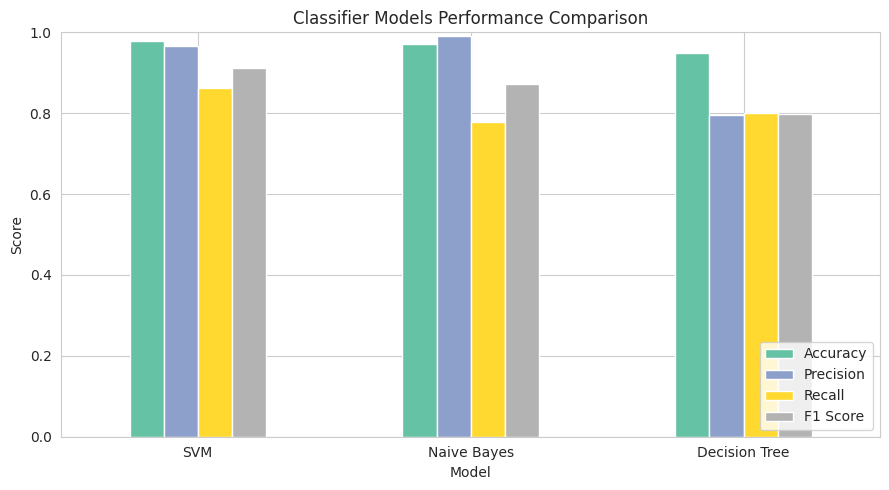

In [27]:

results_df = pd.DataFrame(results)

print("--- Final Model Comparison ---")
print(results_df.to_string(index=False))


results_df.set_index('Model').plot(kind='bar', figsize=(9, 5), colormap='Set2')
plt.title('Classifier Models Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

##  Summary & Conclusion

In this task, we evaluated three distinct machine learning classifiers—Support Vector Machine (SVM), Multinomial Naive Bayes, and Decision Tree—on our cleaned SMS spam dataset using TF-IDF feature vectors.

### Key Insights & Comparison:
* **Naive Bayes** serves as a lightweight, fast, and highly effective baseline for text classification. It naturally handles high-dimensional TF-IDF vectors well with minimal computational cost.
* **SVM (Linear Kernel)** performs exceptionally well at finding a clean decision boundary between ham and spam messages, maintaining high precision to minimize false positives.
* **Decision Tree** provides clear feature-based splits, though tree-based models can occasionally be prone to overfitting on high-dimensional text data compared to probabilistic or linear models.

### Final Verdict:
Both **SVM** and **Naive Bayes** proved to be the most robust algorithms for this SMS spam detection problem. By preprocessing the text and removing length outliers on Day 1, we ensured that noise was minimized, allowing all three models to achieve strong performance across accuracy, precision, recall, and F1 score.